# Hamiltonian QRC SHAP Feature Selection

This notebook builds a lightweight XGBoost proxy for the tabular previous-event features used by `Hamiltonian-QRC(Best).ipynb`, computes SHAP importances, and recommends which sequential rotation-angle features to keep for QRC encoding.

The QRC input window is `n_previous_events + 1 = 21` event rows by six base features. Feature names follow `feature-lag`, where lag `0` is the current event and lags `1..20` are previous events.


In [60]:
from pathlib import Path
import sys

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    def root_mean_squared_error(y_true, y_pred):
        return float(np.sqrt(mean_squared_error(y_true, y_pred)))
import shap
import xgboost as xgb
from xgboost import XGBRegressor

CWD = Path.cwd().resolve()
REPO_ROOT = CWD.parent if CWD.name == "Classical" else CWD
CLASSICAL_DIR = REPO_ROOT / "Classical" if (REPO_ROOT / "Classical").exists() else CWD
sys.path.insert(0, str(CLASSICAL_DIR))

from Preprocess import preprocess_data_window

DATA_CSV = REPO_ROOT / "Whillians-GPS-Data-and-Features.csv"
FILTERED_CSV = REPO_ROOT / "filtered_time_to_next_event.csv"
OUTPUT_DIR = CLASSICAL_DIR / "results" / "hamiltonian_shap_feature_selection"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

N_PREVIOUS_EVENTS = 20
SHORT_THRESHOLD = 64875
RANDOM_STATE = 42

print(f"Output directory: {OUTPUT_DIR}")


Output directory: /Users/noah/repos/Icequake-QRC-/Classical/results/hamiltonian_shap_feature_selection


In [61]:
def apply_hamiltonian_style():
    mpl.rcParams.update({
        "font.family": "Arial",
        "font.size": 11,
        "axes.labelsize": 11,
        "axes.titlesize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "axes.linewidth": 2.0,
        "axes.grid": False,
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
    })


def box_axes(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(2.0)


apply_hamiltonian_style()


## Load the Same Windowed Features

This reuses `Preprocess.preprocess_data_window` so the feature order and lag naming match the Hamiltonian notebook and `scale_to_pi_range` angle encoding.


In [62]:
data_orig = pd.read_csv(DATA_CSV)
filtered_time = pd.read_csv(FILTERED_CSV)

X_train, X_val, X_test, y_train, y_val, y_test, feature_cols = preprocess_data_window(
    filtered_time, data_orig, N_PREVIOUS_EVENTS, random_state=RANDOM_STATE
)

feature_names = list(X_train.columns)
feature_map = pd.DataFrame({"feature": feature_names})
feature_map["base_feature"] = feature_map["feature"].str.rsplit("-", n=1).str[0]
feature_map["lag"] = feature_map["feature"].str.rsplit("-", n=1).str[1].astype(int)
feature_map["is_previous_event"] = feature_map["lag"] > 0

print(f"Train/val/test shapes: {X_train.shape}, {X_val.shape}, {X_test.shape}")
print(f"Base features: {feature_cols}")
display(feature_map.head(12))


X shape:  (2822, 126)
y shape:  (2822,)
Train/val/test shapes: (1692, 126), (565, 126), (565, 126)
Base features: ['tide_deriv', 'form_fac', 'time_since', 'slip_size', 'high_t_evt', 'tide_height']


,feature,base_feature,lag,is_previous_event
0,tide_deriv-0,tide_deriv,0,False
1,form_fac-0,form_fac,0,False
2,time_since-0,time_since,0,False
3,slip_size-0,slip_size,0,False
4,high_t_evt-0,high_t_evt,0,False
5,tide_height-0,tide_height,0,False
6,tide_deriv-1,tide_deriv,1,True
7,form_fac-1,form_fac,1,True
8,time_since-1,time_since,1,True
9,slip_size-1,slip_size,1,True


## Train XGBoost Proxy

The proxy predicts the same target directly from tabular event-window features. It is not a replacement for QRC; it is a fast explainer model for deciding which angle-encoded inputs carry signal.


In [63]:
proxy_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=800,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=2,
    reg_alpha=1e-3,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    tree_method="hist",
    early_stopping_rounds=75,
)

proxy_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

val_pred = proxy_model.predict(X_val)
test_pred = proxy_model.predict(X_test)
proxy_metrics = {
    "val_mae": float(mean_absolute_error(y_val, val_pred)),
    "val_rmse": float(root_mean_squared_error(y_val, val_pred)),
    "val_r2": float(r2_score(y_val, val_pred)),
    "test_mae": float(mean_absolute_error(y_test, test_pred)),
    "test_rmse": float(root_mean_squared_error(y_test, test_pred)),
    "test_r2": float(r2_score(y_test, test_pred)),
}
proxy_metrics


{'val_mae': 12974.206073700221,
 'val_rmse': 16886.808204136254,
 'val_r2': 0.2916405530762307,
 'test_mae': 11595.419427544248,
 'test_rmse': 15236.857543607219,
 'test_r2': 0.42765503451915843}

## Compute SHAP Importances

Mean absolute SHAP values are computed on validation data, then grouped by lag and by base feature. The selection table keeps current-event features by default and flags low-contribution previous-event angle features using transparent thresholds.

The helper below first uses `shap.TreeExplainer`. If SHAP cannot parse a newer XGBoost model serialization such as a bracketed `base_score`, it falls back to XGBoost's native `pred_contribs=True` path, which returns SHAP-style feature contributions plus a final bias column.


In [64]:
def _normalize_shap_values(values, list_index=0):
    if isinstance(values, list):
        values = values[list_index]
    values = np.asarray(values)
    if values.ndim == 3 and values.shape[0] == 1:
        values = values[0]
    if values.ndim != 2:
        raise ValueError(f"Expected 2-D SHAP values, got shape {values.shape}")
    return values


def _xgboost_pred_contribs(model, X, feature_names):
    if not hasattr(model, "get_booster"):
        raise TypeError("XGBoost contribution fallback requires a fitted XGBoost sklearn model.")

    names = list(X.columns) if isinstance(X, pd.DataFrame) else list(feature_names)
    dmatrix = xgb.DMatrix(X, feature_names=names)
    predict_kwargs = {"pred_contribs": True}
    best_iteration = getattr(model, "best_iteration", None)
    if best_iteration is not None:
        predict_kwargs["iteration_range"] = (0, best_iteration + 1)

    contributions = np.asarray(model.get_booster().predict(dmatrix, **predict_kwargs))
    if contributions.ndim == 3:
        contributions = contributions[0]
    if contributions.shape[1] != len(names) + 1:
        raise ValueError(
            f"Expected {len(names) + 1} contribution columns including bias, got {contributions.shape[1]}."
        )
    return contributions[:, :-1]


def get_tree_shap_values(model, X, feature_names, list_index=0):
    try:
        explainer = shap.TreeExplainer(model)
        values = _normalize_shap_values(explainer.shap_values(X), list_index=list_index)
        return values, "shap.TreeExplainer"
    except ValueError as exc:
        message = str(exc)
        is_xgboost_model = hasattr(model, "get_booster")
        is_base_score_parse_error = "base_score" in message or "could not convert string to float" in message
        if not (is_xgboost_model and is_base_score_parse_error):
            raise
        values = _xgboost_pred_contribs(model, X, feature_names)
        return values, "xgboost.Booster.predict(pred_contribs=True)"


shap_values, shap_method = get_tree_shap_values(proxy_model, X_val, feature_names)
print(f"SHAP extraction method: {shap_method}")

mean_abs = np.abs(shap_values).mean(axis=0)
importance = feature_map.copy()
importance["mean_abs_shap"] = mean_abs
importance = importance.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
importance["relative_importance"] = importance["mean_abs_shap"] / importance["mean_abs_shap"].sum()
importance["cumulative_importance"] = importance["relative_importance"].cumsum()

display(importance.head(20))


SHAP extraction method: xgboost.Booster.predict(pred_contribs=True)


,feature,base_feature,lag,is_previous_event,mean_abs_shap,relative_importance,cumulative_importance
0,form_fac-0,form_fac,0,False,3071.488525,0.078880,0.078880
1,tide_height-1,tide_height,1,True,2893.788818,0.074316,0.153196
2,time_since-0,time_since,0,False,1791.491211,0.046008,0.199204
3,slip_size-0,slip_size,0,False,1729.154419,0.044407,0.243610
4,tide_height-0,tide_height,0,False,1508.997803,0.038753,0.282363
5,tide_height-2,tide_height,2,True,1201.012695,0.030844,0.313207
6,tide_deriv-1,tide_deriv,1,True,1121.901245,0.028812,0.342019
7,form_fac-4,form_fac,4,True,1070.455688,0.027491,0.369509
8,form_fac-6,form_fac,6,True,1053.458740,0.027054,0.396563
9,time_since-1,time_since,1,True,1032.717773,0.026521,0.423085


In [65]:
# Thresholds are intentionally simple and visible. Adjust after reviewing plots.
MIN_RELATIVE_IMPORTANCE = 0.0025      # Drop past-event angle features below 0.25% contribution.
CUMULATIVE_KEEP_FLOOR = 0.98          # Also flag the low tail after 98% cumulative importance.
ALWAYS_KEEP_CURRENT_EVENT = True      # Lag 0 is not a previous-event feature.

selection = importance.copy()
low_relative = selection["relative_importance"] < MIN_RELATIVE_IMPORTANCE
low_tail = selection["cumulative_importance"] > CUMULATIVE_KEEP_FLOOR
previous_event = selection["is_previous_event"]
selection["drop_candidate"] = previous_event & (low_relative | low_tail)
if ALWAYS_KEEP_CURRENT_EVENT:
    selection.loc[selection["lag"] == 0, "drop_candidate"] = False
selection["recommendation"] = np.where(selection["drop_candidate"], "flag/drop for angle encoding", "keep")

selection_by_feature = selection.set_index("feature").loc[feature_names]
selected_feature_keep_mask = ~selection_by_feature["drop_candidate"].to_numpy()
recommended_angle_features = selection_by_feature.index[selected_feature_keep_mask].tolist()
flagged_angle_features = selection_by_feature.index[~selected_feature_keep_mask].tolist()

n_events = N_PREVIOUS_EVENTS + 1
n_features_per_event = len(feature_cols)
angle_keep_mask = selected_feature_keep_mask.reshape(n_events, n_features_per_event)
angle_keep_mask_df = pd.DataFrame(
    angle_keep_mask,
    index=pd.Index(range(n_events), name="event_lag"),
    columns=feature_cols,
)

print(f"Keep {len(recommended_angle_features)} / {len(selection)} angle features")
print(f"Flag/drop {len(flagged_angle_features)} low-contribution previous-event features")
print(f"Angle mask shape: {angle_keep_mask.shape} = (n_events, n_features_per_event)")
display(selection.sort_values(["drop_candidate", "lag", "base_feature"]).reset_index(drop=True))
display(angle_keep_mask_df)

X_train_selected = X_train.loc[:, recommended_angle_features]
X_val_selected = X_val.loc[:, recommended_angle_features]
X_test_selected = X_test.loc[:, recommended_angle_features]

reduced_proxy_model = XGBRegressor(**proxy_model.get_params())
reduced_proxy_model.fit(
    X_train_selected,
    y_train,
    eval_set=[(X_val_selected, y_val)],
    verbose=False,
)

reduced_val_pred = reduced_proxy_model.predict(X_val_selected)
reduced_test_pred = reduced_proxy_model.predict(X_test_selected)
full_vs_reduced_proxy_validation = pd.DataFrame([
    {
        "feature_set": "full",
        "n_features": len(feature_names),
        "val_mae": proxy_metrics["val_mae"],
        "val_rmse": proxy_metrics["val_rmse"],
        "val_r2": proxy_metrics["val_r2"],
        "test_mae": proxy_metrics["test_mae"],
        "test_rmse": proxy_metrics["test_rmse"],
        "test_r2": proxy_metrics["test_r2"],
    },
    {
        "feature_set": "selected_angle_mask",
        "n_features": len(recommended_angle_features),
        "val_mae": float(mean_absolute_error(y_val, reduced_val_pred)),
        "val_rmse": float(root_mean_squared_error(y_val, reduced_val_pred)),
        "val_r2": float(r2_score(y_val, reduced_val_pred)),
        "test_mae": float(mean_absolute_error(y_test, reduced_test_pred)),
        "test_rmse": float(root_mean_squared_error(y_test, reduced_test_pred)),
        "test_r2": float(r2_score(y_test, reduced_test_pred)),
    },
])

display(full_vs_reduced_proxy_validation)


Keep 95 / 126 angle features
Flag/drop 31 low-contribution previous-event features
Angle mask shape: (21, 6) = (n_events, n_features_per_event)


,feature,base_feature,lag,is_previous_event,mean_abs_shap,relative_importance,cumulative_importance,drop_candidate,recommendation
0,form_fac-0,form_fac,0,False,3071.488525,0.078880,0.078880,False,keep
1,high_t_evt-0,high_t_evt,0,False,87.136765,0.002238,0.987927,False,keep
2,slip_size-0,slip_size,0,False,1729.154419,0.044407,0.243610,False,keep
3,tide_deriv-0,tide_deriv,0,False,938.128540,0.024092,0.447177,False,keep
4,tide_height-0,tide_height,0,False,1508.997803,0.038753,0.282363,False,keep
...,...,...,...,...,...,...,...,...,...
121,high_t_evt-18,high_t_evt,18,True,16.114391,0.000414,0.998462,True,flag/drop for angle encoding
122,form_fac-19,form_fac,19,True,86.609726,0.002224,0.990152,True,flag/drop for angle encoding
123,high_t_evt-19,high_t_evt,19,True,3.330603,0.000086,0.999631,True,flag/drop for angle encoding
124,high_t_evt-20,high_t_evt,20,True,3.291935,0.000085,0.999715,True,flag/drop for angle encoding


,tide_deriv,form_fac,time_since,slip_size,high_t_evt,tide_height
event_lag,,,,,,
0,True,True,True,True,True,True
1,True,True,True,True,True,True
2,True,True,False,True,False,True
3,True,True,True,True,False,True
4,True,True,True,True,False,True
5,False,True,False,True,False,True
6,True,True,False,True,False,True
7,True,True,False,True,False,True
8,True,True,True,True,False,True


,feature_set,n_features,val_mae,val_rmse,val_r2,test_mae,test_rmse,test_r2
0,full,126,12974.206074,16886.808204,0.291641,11595.419428,15236.857544,0.427655
1,selected_angle_mask,95,13004.623023,16858.954723,0.293975,11613.067678,15323.196692,0.421150


## Grouped Views for Angle-Encoding Decisions

These plots show whether importance decays by event lag and which base signals dominate across the history window.


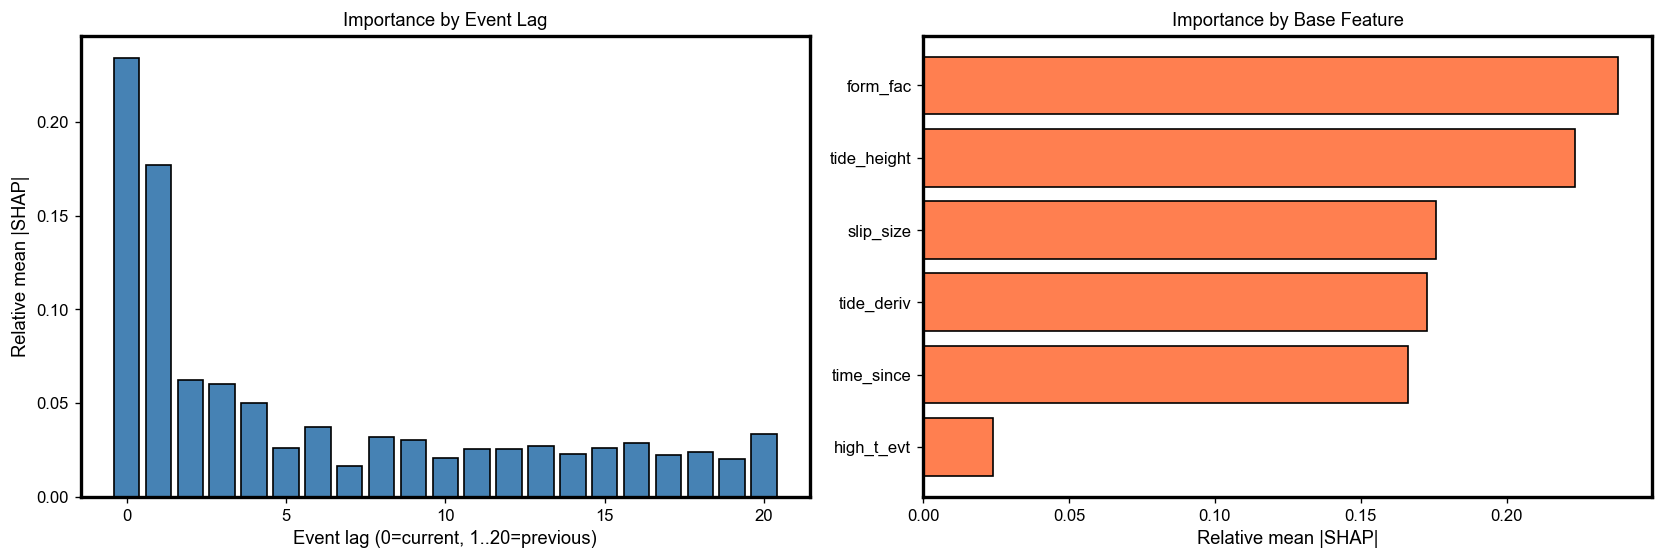

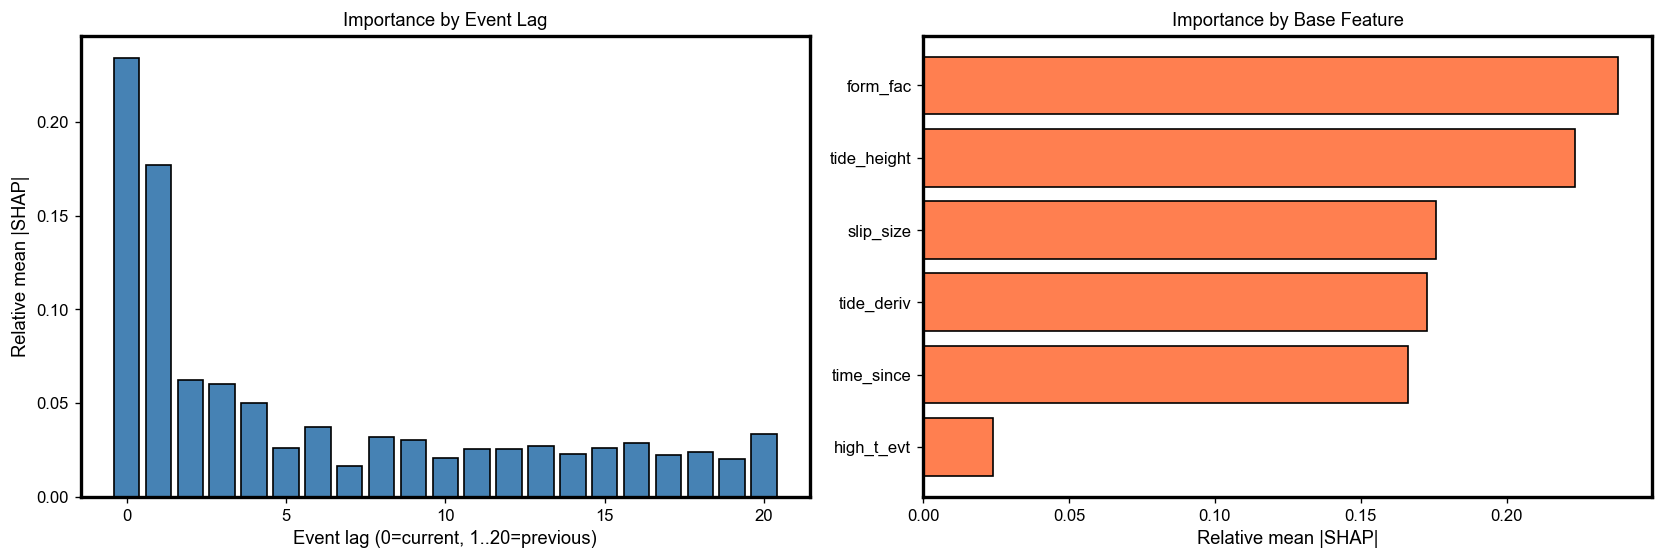

In [66]:
lag_importance = selection.groupby("lag", as_index=False)["mean_abs_shap"].sum()
lag_importance["relative_importance"] = lag_importance["mean_abs_shap"] / lag_importance["mean_abs_shap"].sum()
base_importance = selection.groupby("base_feature", as_index=False)["mean_abs_shap"].sum()
base_importance["relative_importance"] = base_importance["mean_abs_shap"] / base_importance["mean_abs_shap"].sum()
base_importance = base_importance.sort_values("mean_abs_shap", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].bar(lag_importance["lag"], lag_importance["relative_importance"], color="steelblue", edgecolor="black")
axes[0].set_xlabel("Event lag (0=current, 1..20=previous)")
axes[0].set_ylabel("Relative mean |SHAP|")
axes[0].set_title("Importance by Event Lag")

axes[1].barh(base_importance["base_feature"], base_importance["relative_importance"], color="coral", edgecolor="black")
axes[1].set_xlabel("Relative mean |SHAP|")
axes[1].set_title("Importance by Base Feature")

for ax in axes:
    box_axes(ax)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "shap_grouped_importance.png")

fig


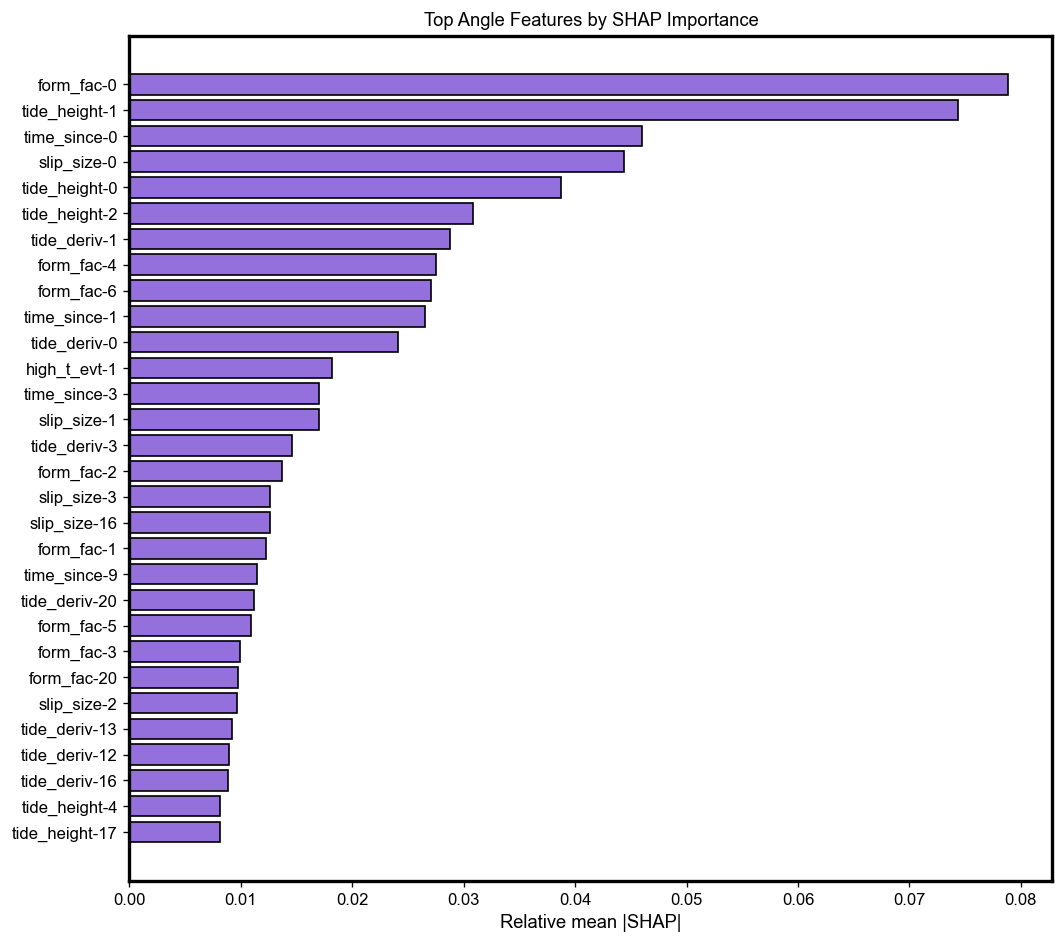

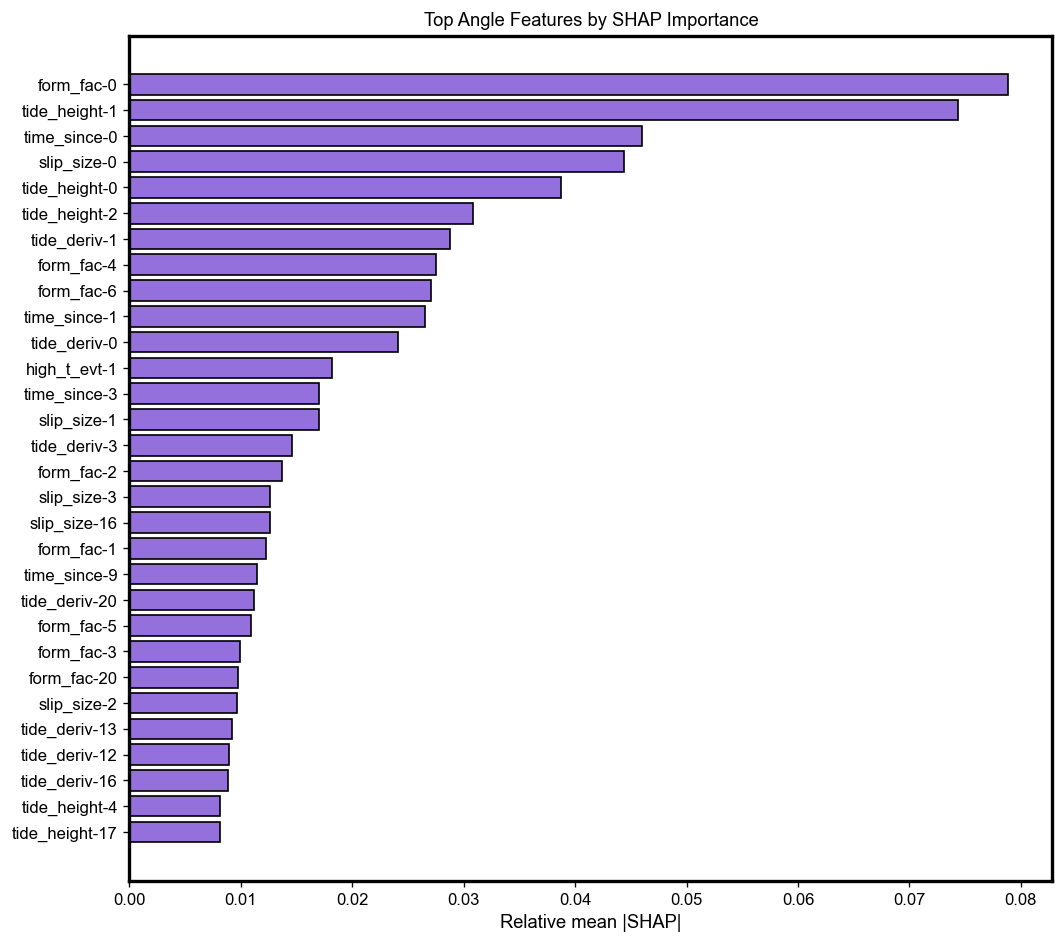

In [ ]:
plot_df = selection.sort_values("mean_abs_shap", ascending=True)#.tail(30)
colors = np.where(plot_df["drop_candidate"], "lightgrey", "mediumpurple")
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(plot_df["feature"], plot_df["relative_importance"], color=colors, edgecolor="black")
ax.set_xlabel("Relative mean |SHAP|")
ax.set_title("Top Angle Features by SHAP Importance")
box_axes(ax)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "shap_top_angle_features.png")
fig


## Optional SHAP Beeswarm

This cell uses SHAP's native visualization for the highest-impact features. It can be skipped if you only need the selection table.


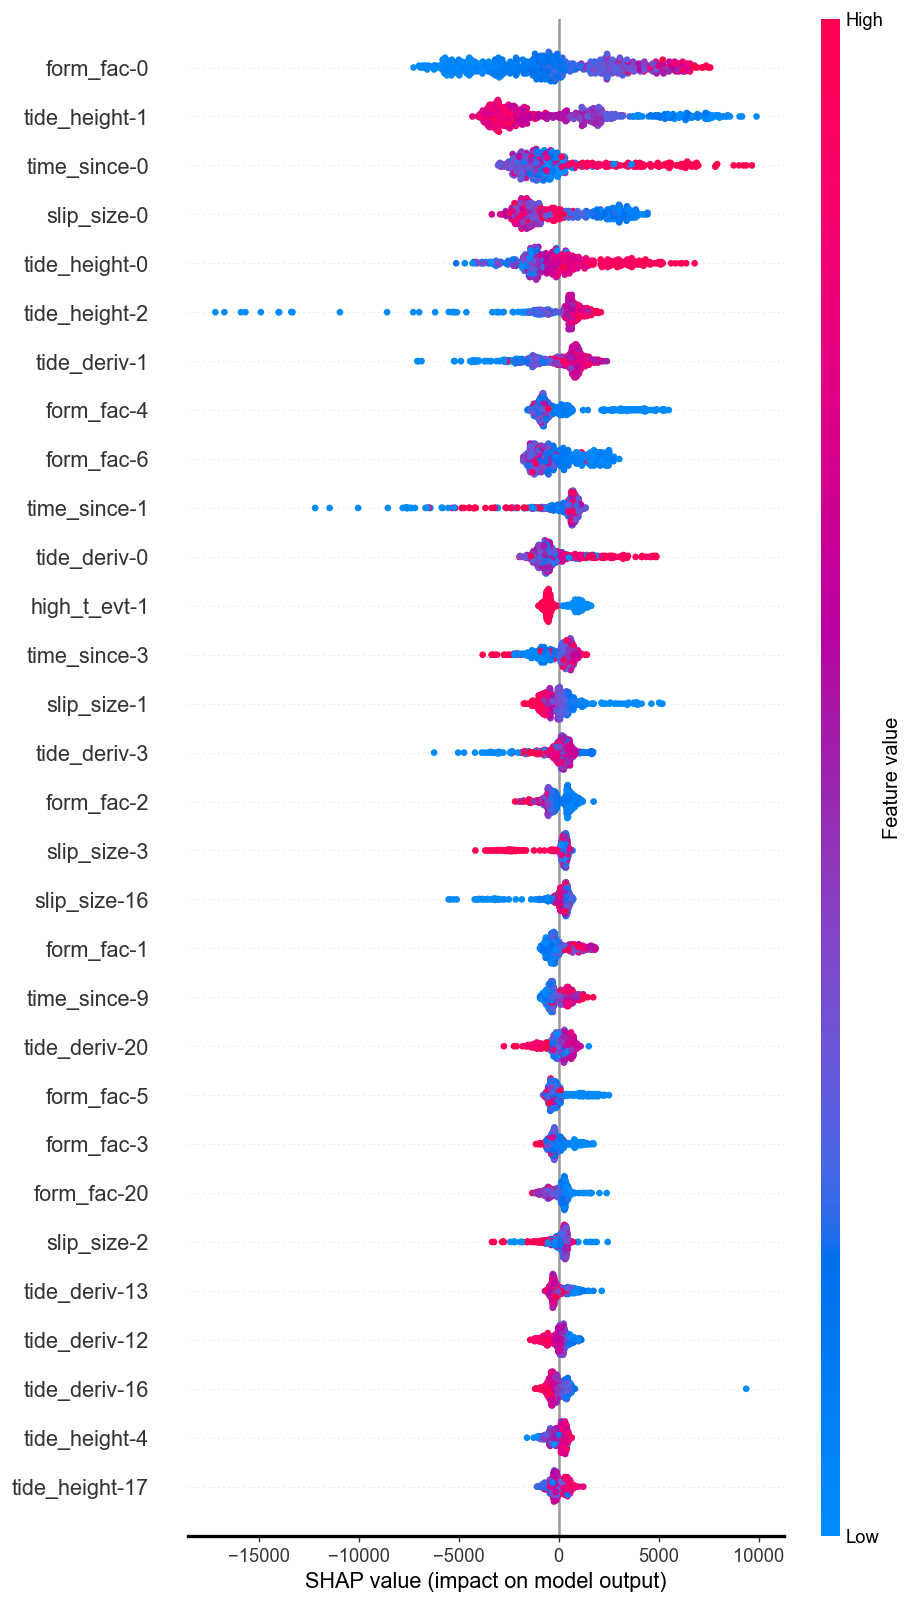

In [68]:
shap.summary_plot(
    shap_values,
    X_val,
    feature_names=feature_names,
    max_display=30,
    show=False,
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_beeswarm_top30.png", dpi=300, bbox_inches="tight")
plt.show()


## Export Recommended Angle Feature List and Mask

Use `recommended_angle_features` as the reduced flat feature list for tabular proxy checks. For QRC angle encoding, prefer the exported `angle_keep_mask`, which preserves the `(n_events, n_features_per_event)` layout: rows are event lags `0..N_PREVIOUS_EVENTS`, columns are the base features in encoding order.


In [69]:
selection_out = selection.sort_values(["drop_candidate", "lag", "base_feature"]).reset_index(drop=True)
selection_out["min_relative_importance"] = MIN_RELATIVE_IMPORTANCE
selection_out["cumulative_keep_floor"] = CUMULATIVE_KEEP_FLOOR
selection_out.to_csv(OUTPUT_DIR / "shap_angle_feature_selection.csv", index=False)
angle_keep_mask_df.to_csv(OUTPUT_DIR / "recommended_angle_feature_mask.csv")
full_vs_reduced_proxy_validation.to_csv(OUTPUT_DIR / "full_vs_reduced_proxy_validation.csv", index=False)
np.save(OUTPUT_DIR / "recommended_angle_feature_mask.npy", angle_keep_mask)
np.savez(
    OUTPUT_DIR / "recommended_angle_feature_mask.npz",
    keep_mask=angle_keep_mask,
    event_lags=np.arange(n_events),
    base_features=np.array(feature_cols),
    flat_feature_names=np.array(feature_names),
)

with (OUTPUT_DIR / "recommended_angle_features.txt").open("w", encoding="utf-8") as f:
    for name in recommended_angle_features:
        f.write(f"{name}\n")

print("Recommended angle features:")
print(recommended_angle_features)
print(f"Angle mask shape: {angle_keep_mask.shape}")
print(f"\nWrote selection outputs to {OUTPUT_DIR}")


Recommended angle features:
['tide_deriv-0', 'form_fac-0', 'time_since-0', 'slip_size-0', 'high_t_evt-0', 'tide_height-0', 'tide_deriv-1', 'form_fac-1', 'time_since-1', 'slip_size-1', 'high_t_evt-1', 'tide_height-1', 'tide_deriv-2', 'form_fac-2', 'slip_size-2', 'tide_height-2', 'tide_deriv-3', 'form_fac-3', 'time_since-3', 'slip_size-3', 'tide_height-3', 'tide_deriv-4', 'form_fac-4', 'time_since-4', 'slip_size-4', 'tide_height-4', 'form_fac-5', 'slip_size-5', 'tide_height-5', 'tide_deriv-6', 'form_fac-6', 'slip_size-6', 'tide_height-6', 'tide_deriv-7', 'form_fac-7', 'slip_size-7', 'tide_height-7', 'tide_deriv-8', 'form_fac-8', 'time_since-8', 'slip_size-8', 'tide_height-8', 'tide_deriv-9', 'time_since-9', 'slip_size-9', 'tide_height-9', 'tide_deriv-10', 'form_fac-10', 'time_since-10', 'slip_size-10', 'tide_deriv-11', 'form_fac-11', 'time_since-11', 'slip_size-11', 'tide_height-11', 'tide_deriv-12', 'form_fac-12', 'time_since-12', 'slip_size-12', 'tide_deriv-13', 'time_since-13', 'slip_

## QRC Validation With Masked Angle Features

This section compares the Hamiltonian QRC pipeline with the full angle-encoded feature layout versus the same fixed layout after SHAP-flagged angles are neutralized. The `(21, 6)` event/qubit layout is preserved; unimportant angles are replaced with `QRC_NEUTRAL_ANGLE` instead of physically dropping columns.

By default `QRC_NEUTRAL_ANGLE = 0.0`, which corresponds to no `RY` rotation contribution from the masked feature. Set it to `np.pi / 2` if you prefer the train-range midpoint as the neutral angle. The expensive QRC path is gated by `RUN_QRC_VALIDATION = False` so the notebook will not launch the reservoir simulation unless explicitly enabled.

In [70]:
def scale_to_pi_range_df(X_train_df, X_val_df, X_test_df):
    """Scale feature DataFrames to RY angles in [0, pi] using train-set ranges."""
    train_min = X_train_df.min(axis=0)
    train_max = X_train_df.max(axis=0)
    denom = (train_max - train_min).replace(0, 1.0)

    def transform(X_df):
        scaled = (X_df - train_min) / denom
        scaled = scaled.clip(lower=0.0, upper=1.0)
        return pd.DataFrame(
            scaled.to_numpy(dtype=float) * np.pi,
            index=X_df.index,
            columns=X_df.columns,
        )

    return transform(X_train_df), transform(X_val_df), transform(X_test_df)


def apply_angle_mask(X_q, angle_mask, neutral_angle=0.0):
    """Neutralize masked angle positions while preserving flat column order and index."""
    keep_mask = np.asarray(angle_mask, dtype=bool)
    if keep_mask.ndim != 2:
        raise ValueError(f"angle_mask must be 2-D, got shape {keep_mask.shape}")

    n_events_mask, n_features_mask = keep_mask.shape
    expected_cols = n_events_mask * n_features_mask
    if X_q.shape[1] != expected_cols:
        raise ValueError(
            f"X_q has {X_q.shape[1]} columns, but angle_mask expects {expected_cols} "
            f"({n_events_mask} events x {n_features_mask} features)."
        )

    is_dataframe = isinstance(X_q, pd.DataFrame)
    values = X_q.to_numpy(dtype=float, copy=True) if is_dataframe else np.array(X_q, dtype=float, copy=True)
    values_3d = values.reshape(values.shape[0], n_events_mask, n_features_mask)
    values_3d[:, ~keep_mask] = neutral_angle
    masked_values = values_3d.reshape(values.shape)

    if is_dataframe:
        return pd.DataFrame(masked_values, index=X_q.index, columns=X_q.columns)
    return masked_values


def regression_metrics(y_true, y_pred, prefix=""):
    """Return MAE/RMSE/R2 metrics with a fallback for older scikit-learn versions."""
    y_true_arr = np.asarray(y_true)
    y_pred_arr = np.asarray(y_pred)
    try:
        rmse = root_mean_squared_error(y_true_arr, y_pred_arr)
    except NameError:
        rmse = np.sqrt(mean_squared_error(y_true_arr, y_pred_arr))

    return {
        f"{prefix}mae": float(mean_absolute_error(y_true_arr, y_pred_arr)),
        f"{prefix}rmse": float(rmse),
        f"{prefix}r2": float(r2_score(y_true_arr, y_pred_arr)),
    }


def maybe_subset_qrc_split(X_train_q, X_val_q, X_test_q, y_train, y_val, y_test, subset_size, random_state=RANDOM_STATE):
    """Optionally take a deterministic subset so QRC validation can be smoke-tested."""
    if subset_size is None:
        return X_train_q, X_val_q, X_test_q, np.asarray(y_train), np.asarray(y_val), np.asarray(y_test)

    rng = np.random.default_rng(random_state)

    def subset_xy(X_df, y_arr):
        y_arr = np.asarray(y_arr)
        n_keep = min(int(subset_size), len(X_df))
        if n_keep <= 0:
            raise ValueError("subset_size must be positive when provided")
        idx = np.sort(rng.choice(len(X_df), size=n_keep, replace=False))
        return X_df.iloc[idx].reset_index(drop=True), y_arr[idx]

    X_tr, y_tr = subset_xy(X_train_q, y_train)
    X_vl, y_vl = subset_xy(X_val_q, y_val)
    X_te, y_te = subset_xy(X_test_q, y_test)
    return X_tr, X_vl, X_te, y_tr, y_vl, y_te

In [71]:
QRC_NEUTRAL_ANGLE = 0.0  # Alternative: np.pi / 2 for train-range midpoint neutrality.

X_train_q_full, X_val_q_full, X_test_q_full = scale_to_pi_range_df(X_train, X_val, X_test)
X_train_q_masked = apply_angle_mask(X_train_q_full, angle_keep_mask, neutral_angle=QRC_NEUTRAL_ANGLE)
X_val_q_masked = apply_angle_mask(X_val_q_full, angle_keep_mask, neutral_angle=QRC_NEUTRAL_ANGLE)
X_test_q_masked = apply_angle_mask(X_test_q_full, angle_keep_mask, neutral_angle=QRC_NEUTRAL_ANGLE)

assert list(X_train_q_masked.columns) == feature_names
assert list(X_val_q_masked.columns) == feature_names
assert list(X_test_q_masked.columns) == feature_names
assert X_train_q_masked.index.equals(X_train_q_full.index)
assert X_val_q_masked.index.equals(X_val_q_full.index)
assert X_test_q_masked.index.equals(X_test_q_full.index)

n_masked_angles = int((~angle_keep_mask).sum())
print(f"Built full and masked QRC angle DataFrames with {n_masked_angles} masked angles per sample.")
print(f"Neutral angle: {QRC_NEUTRAL_ANGLE:.4f} radians")
print(f"Masked train/val/test shapes: {X_train_q_masked.shape}, {X_val_q_masked.shape}, {X_test_q_masked.shape}")

Built full and masked QRC angle DataFrames with 31 masked angles per sample.
Neutral angle: 0.0000 radians
Masked train/val/test shapes: (1692, 126), (565, 126), (565, 126)


In [72]:
def ensure_qrc_dependencies():
    """Import QRC-only dependencies lazily so skipped validation cells remain lightweight."""
    global QuantumCircuit, AerSimulator, KMeans, XGBClassifier, compute_sample_weight
    try:
        from qiskit import QuantumCircuit
        from qiskit_aer import AerSimulator
        from sklearn.cluster import KMeans
        from sklearn.utils.class_weight import compute_sample_weight
        from xgboost import XGBClassifier
    except ImportError as exc:
        raise ImportError(
            "QRC validation requires qiskit, qiskit-aer, scikit-learn, and xgboost. "
            "Install/activate the Hamiltonian QRC environment before setting RUN_QRC_VALIDATION=True."
        ) from exc


def generate_ising_params(n_qubits, rng, J_std=0.5, h=1.0, t=0.5):
    J = np.zeros((n_qubits, n_qubits))
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            J[i, j] = rng.normal(0, J_std)
    return J, h, t


def trotter_ising_layer(qc, n_qubits, J, h, t, n_trotter_steps=3):
    dt = t / n_trotter_steps
    for _ in range(n_trotter_steps):
        for i in range(n_qubits):
            for j in range(i + 1, n_qubits):
                if abs(J[i, j]) > 1e-10:
                    qc.cx(i, j)
                    qc.rz(2 * J[i, j] * dt, j)
                    qc.cx(i, j)
        for i in range(n_qubits):
            qc.rx(2 * h * dt, i)


def encode_rotations(qc, data_sample, n_qubits):
    for i in range(n_qubits):
        qc.ry(float(data_sample[i]), i)


def build_reservoir_circuit_rotations(data_sample, ising_params, num_layers, n_qubits):
    J, h, t = ising_params
    qc = QuantumCircuit(n_qubits)
    for i in range(n_qubits):
        qc.h(i)

    encode_rotations(qc, data_sample, n_qubits)
    qc.barrier()
    for _ in range(num_layers):
        trotter_ising_layer(qc, n_qubits, J, h, t)
        qc.barrier()
        encode_rotations(qc, data_sample, n_qubits)
        qc.barrier()
        trotter_ising_layer(qc, n_qubits, J, h, t)
        qc.barrier()
    return qc


def generate_random_angles(num_layers, n_qubits, rng):
    return generate_ising_params(n_qubits, rng)


def get_pauli_expectations(circuit_base, n_qubits, shots, simulator):
    expectations = np.zeros(3 * n_qubits)
    for basis_idx, basis in enumerate(["Z", "X", "Y"]):
        qc_meas = circuit_base.copy()
        if basis == "X":
            for i in range(n_qubits):
                qc_meas.h(i)
        elif basis == "Y":
            for i in range(n_qubits):
                qc_meas.sdg(i)
                qc_meas.h(i)

        qc_meas.measure_all()
        result = simulator.run(qc_meas, shots=shots).result()
        for bitstring, count in result.get_counts().items():
            bits = bitstring.replace(" ", "")
            for qubit_idx in range(n_qubits):
                bit = int(bits[n_qubits - 1 - qubit_idx])
                expectations[basis_idx * n_qubits + qubit_idx] += (1 - 2 * bit) * count / shots

    zz_correlators = np.zeros(n_qubits)
    qc_zz = circuit_base.copy()
    qc_zz.measure_all()
    result_zz = simulator.run(qc_zz, shots=shots).result()
    for bitstring, count in result_zz.get_counts().items():
        bits = bitstring.replace(" ", "")
        for i in range(n_qubits):
            j = (i + 1) % n_qubits
            bit_i = int(bits[n_qubits - 1 - i])
            bit_j = int(bits[n_qubits - 1 - j])
            zz_correlators[i] += (1 - 2 * bit_i) * (1 - 2 * bit_j) * count / shots

    return np.concatenate([expectations, zz_correlators])


def run_quantum_reservoir_pauli(X_data, angle_bank, num_layers, n_qubits, n_total_events, shots):
    X_array = X_data.to_numpy(dtype=float) if hasattr(X_data, "to_numpy") else np.asarray(X_data, dtype=float)
    n_samples = X_array.shape[0]
    n_obs = 4 * n_qubits
    simulator = AerSimulator()
    pauli_matrix = np.zeros((n_samples, n_total_events * n_obs))

    for event_idx in range(n_total_events):
        start_col = event_idx * n_qubits
        end_col = start_col + n_qubits
        X_event = X_array[:, start_col:end_col]
        ising_params = angle_bank[event_idx]

        for sample_idx in range(n_samples):
            qc = build_reservoir_circuit_rotations(X_event[sample_idx], ising_params, num_layers, n_qubits)
            obs_vals = get_pauli_expectations(qc, n_qubits, shots, simulator)
            pauli_matrix[sample_idx, event_idx * n_obs:(event_idx + 1) * n_obs] = obs_vals

        print(f"  Event {event_idx + 1}/{n_total_events} done", end="\r")

    print()
    return pauli_matrix


def make_hybrid_features_decay(P_matrix, X_classical=None, n_total_events=None, n_obs=None, decay=0.3):
    """Apply the Hamiltonian notebook's exponential event decay to quantum features."""
    if n_total_events is None or n_obs is None:
        raise ValueError("n_total_events and n_obs are required")

    weights = np.array([np.exp(-decay * (n_total_events - 1 - i)) for i in range(n_total_events)])
    weights /= weights.sum()

    weighted_P = P_matrix.copy()
    for event_idx in range(n_total_events):
        start = event_idx * n_obs
        end = start + n_obs
        weighted_P[:, start:end] *= weights[event_idx]
    return weighted_P

In [73]:
def _fit_qrc_regressor(X_train_h, y_train_arr, X_val_h, y_val_arr, random_state):
    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=600,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=2,
        reg_alpha=1e-3,
        reg_lambda=1.0,
        random_state=random_state,
        tree_method="hist",
        early_stopping_rounds=50,
    )
    model.fit(X_train_h, y_train_arr, eval_set=[(X_val_h, y_val_arr)], verbose=False)
    return model


def _run_single_mask_qrc_iteration(
    iteration_idx,
    X_train_q,
    X_val_q,
    X_test_q,
    y_train_arr,
    y_val_arr,
    y_test_arr,
    y_regime_train,
    y_regime_val,
    val_route_labels,
    test_route_labels,
    config,
):
    n_qubits = config["n_qubits"]
    n_total_events = config["n_total_events"]
    num_layers = config["num_layers_per_event"]
    shots = config["shots"]
    n_obs = 4 * n_qubits
    seed = config["random_seed"] + iteration_idx

    rng_short = np.random.default_rng(seed)
    rng_long = np.random.default_rng(seed + 10_000)
    angle_bank_short = [generate_random_angles(num_layers, n_qubits, rng_short) for _ in range(n_total_events)]
    angle_bank_long = [generate_random_angles(num_layers, n_qubits, rng_long) for _ in range(n_total_events)]

    train_short_idx = np.where(y_regime_train == 0)[0]
    train_long_idx = np.where(y_regime_train == 1)[0]
    val_short_true_idx = np.where(y_regime_val == 0)[0]
    val_long_true_idx = np.where(y_regime_val == 1)[0]
    val_short_route_idx = np.where(val_route_labels == 0)[0]
    val_long_route_idx = np.where(val_route_labels == 1)[0]
    test_short_route_idx = np.where(test_route_labels == 0)[0]
    test_long_route_idx = np.where(test_route_labels == 1)[0]

    required_groups = {
        "train_short": train_short_idx,
        "train_long": train_long_idx,
        "val_short_true": val_short_true_idx,
        "val_long_true": val_long_true_idx,
    }
    empty_groups = [name for name, idx in required_groups.items() if len(idx) == 0]
    if empty_groups:
        raise ValueError(
            "QRC regime split produced empty groups: "
            f"{empty_groups}. Increase QRC_VALIDATION_SUBSET or use QRC_VALIDATION_SUBSET=None."
        )

    def reservoir_features(X_df, row_idx, angle_bank, label):
        if len(row_idx) == 0:
            return np.empty((0, n_total_events * n_obs))
        print(f"  Running {label} reservoir on {len(row_idx)} samples...")
        P = run_quantum_reservoir_pauli(
            X_df.iloc[row_idx], angle_bank, num_layers, n_qubits, n_total_events, shots
        )
        return make_hybrid_features_decay(P, n_total_events=n_total_events, n_obs=n_obs)

    H_tr_short = reservoir_features(X_train_q, train_short_idx, angle_bank_short, "SHORT/train")
    H_tr_long = reservoir_features(X_train_q, train_long_idx, angle_bank_long, "LONG/train")
    H_vl_short_true = reservoir_features(X_val_q, val_short_true_idx, angle_bank_short, "SHORT/val-train")
    H_vl_long_true = reservoir_features(X_val_q, val_long_true_idx, angle_bank_long, "LONG/val-train")

    model_short = _fit_qrc_regressor(
        H_tr_short, y_train_arr[train_short_idx], H_vl_short_true, y_val_arr[val_short_true_idx], seed
    )
    model_long = _fit_qrc_regressor(
        H_tr_long, y_train_arr[train_long_idx], H_vl_long_true, y_val_arr[val_long_true_idx], seed + 1
    )

    val_pred = np.empty(len(X_val_q), dtype=float)
    if len(val_short_route_idx) > 0:
        H_vl_short_route = reservoir_features(X_val_q, val_short_route_idx, angle_bank_short, "SHORT/val-routed")
        val_pred[val_short_route_idx] = model_short.predict(H_vl_short_route)
    if len(val_long_route_idx) > 0:
        H_vl_long_route = reservoir_features(X_val_q, val_long_route_idx, angle_bank_long, "LONG/val-routed")
        val_pred[val_long_route_idx] = model_long.predict(H_vl_long_route)

    test_pred = np.empty(len(X_test_q), dtype=float)
    if len(test_short_route_idx) > 0:
        H_te_short = reservoir_features(X_test_q, test_short_route_idx, angle_bank_short, "SHORT/test-routed")
        test_pred[test_short_route_idx] = model_short.predict(H_te_short)
    if len(test_long_route_idx) > 0:
        H_te_long = reservoir_features(X_test_q, test_long_route_idx, angle_bank_long, "LONG/test-routed")
        test_pred[test_long_route_idx] = model_long.predict(H_te_long)

    return {
        "iteration": iteration_idx,
        "val_pred": val_pred,
        "test_pred": test_pred,
        **regression_metrics(y_val_arr, val_pred, prefix="val_"),
        **regression_metrics(y_test_arr, test_pred, prefix="test_"),
    }


def run_qrc_mask_pipeline(X_train_q, X_val_q, X_test_q, y_train, y_val, y_test, config):
    ensure_qrc_dependencies()
    X_train_run, X_val_run, X_test_run, y_train_run, y_val_run, y_test_run = maybe_subset_qrc_split(
        X_train_q, X_val_q, X_test_q, y_train, y_val, y_test,
        subset_size=config["subset_size"],
        random_state=config["random_seed"],
    )

    if min(len(X_train_run), len(X_val_run), len(X_test_run)) < 2:
        raise ValueError("Each QRC split must contain at least two samples for regime routing.")

    km_y = KMeans(n_clusters=2, n_init=50, random_state=config["random_seed"])
    km_y.fit(y_train_run.reshape(-1, 1))
    order = np.argsort(km_y.cluster_centers_.ravel())
    remap = {old: new for new, old in enumerate(order)}

    def km_label(y_arr):
        raw = km_y.predict(y_arr.reshape(-1, 1))
        return np.array([remap[label] for label in raw])

    y_regime_train = km_label(y_train_run)
    y_regime_val = km_label(y_val_run)
    y_regime_test = km_label(y_test_run)
    if len(np.unique(y_regime_train)) < 2 or len(np.unique(y_regime_val)) < 2:
        raise ValueError(
            "QRC subset did not include both short and long regimes in train/val. "
            "Increase QRC_VALIDATION_SUBSET or set it to None."
        )

    sample_weights_clf = compute_sample_weight("balanced", y_regime_train)
    slip_classifier = XGBClassifier(
        objective="binary:logistic",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=config["random_seed"],
        eval_metric="logloss",
    )
    slip_classifier.fit(
        X_train_run,
        y_regime_train,
        sample_weight=sample_weights_clf,
        eval_set=[(X_val_run, y_regime_val)],
        verbose=False,
    )
    val_route_labels = slip_classifier.predict(X_val_run)
    test_route_labels = slip_classifier.predict(X_test_run)

    iteration_results = []
    for iteration_idx in config["iterations"]:
        print(f"\nQRC iteration {iteration_idx + 1}")
        result = _run_single_mask_qrc_iteration(
            iteration_idx,
            X_train_run,
            X_val_run,
            X_test_run,
            y_train_run,
            y_val_run,
            y_test_run,
            y_regime_train,
            y_regime_val,
            val_route_labels,
            test_route_labels,
            config,
        )
        print(
            f"  Val MAE: {result['val_mae']:.2f} | Val RMSE: {result['val_rmse']:.2f} | "
            f"Test MAE: {result['test_mae']:.2f} | Test RMSE: {result['test_rmse']:.2f}"
        )
        iteration_results.append(result)

    top_k = min(config["top_k"], len(iteration_results))
    top_results = sorted(iteration_results, key=lambda row: row["val_mae"])[:top_k]
    val_pred = np.mean([row["val_pred"] for row in top_results], axis=0)
    test_pred = np.mean([row["test_pred"] for row in top_results], axis=0)

    return {
        "iterations": iteration_results,
        "top_iterations": [row["iteration"] for row in top_results],
        "val_pred": val_pred,
        "test_pred": test_pred,
        "y_val": y_val_run,
        "y_test": y_test_run,
        "val_route_labels": val_route_labels,
        "test_route_labels": test_route_labels,
        "y_regime_val": y_regime_val,
        "y_regime_test": y_regime_test,
        **regression_metrics(y_val_run, val_pred, prefix="val_"),
        **regression_metrics(y_test_run, test_pred, prefix="test_"),
    }

In [ ]:
RUN_QRC_VALIDATION = True
QRC_VALIDATION_SUBSET = None          # Set to None for the full train/val/test splits.
QRC_VALIDATION_ITERATIONS = [0]     # Add more seeds after the smoke subset works.
QRC_VALIDATION_TOP_K = 3
QRC_SHOTS = 4096                    # Original best notebook used 4096 shots.
QRC_NUM_LAYERS_PER_EVENT = 3
RUN_LIGHTWEIGHT_MASK_SMOKE = True  # Optional non-quantum sanity check.

QRC_MASK_CONFIG = {
    "num_layers_per_event": QRC_NUM_LAYERS_PER_EVENT,
    "shots": QRC_SHOTS,
    "iterations": QRC_VALIDATION_ITERATIONS,
    "top_k": QRC_VALIDATION_TOP_K,
    "random_seed": RANDOM_STATE,
    "subset_size": QRC_VALIDATION_SUBSET,
    "n_qubits": n_features_per_event,
    "n_total_events": n_events,
}

qrc_mask_validation_results = pd.DataFrame()
qrc_mask_validation_predictions = {}


def _summarize_qrc_mask_results(full_result, masked_result):
    rows = []
    for feature_set, result, masked_count in [
        ("full_angles", full_result, 0),
        ("masked_angles", masked_result, n_masked_angles),
    ]:
        rows.append({
            "feature_set": feature_set,
            "n_flat_features": len(feature_names),
            "n_masked_angles": masked_count,
            "neutral_angle": QRC_NEUTRAL_ANGLE,
            "subset_size": QRC_VALIDATION_SUBSET,
            "shots": QRC_SHOTS,
            "iterations": result["top_iterations"],
            "top_k": len(result["top_iterations"]),
            "val_mae": result["val_mae"],
            "val_rmse": result["val_rmse"],
            "val_r2": result["val_r2"],
            "test_mae": result["test_mae"],
            "test_rmse": result["test_rmse"],
            "test_r2": result["test_r2"],
        })

    table = pd.DataFrame(rows)
    delta = {"feature_set": "masked_minus_full"}
    for metric in ["val_mae", "val_rmse", "val_r2", "test_mae", "test_rmse", "test_r2"]:
        delta[metric] = table.loc[table["feature_set"] == "masked_angles", metric].iloc[0] - table.loc[
            table["feature_set"] == "full_angles", metric
        ].iloc[0]
    return pd.concat([table, pd.DataFrame([delta])], ignore_index=True)


if RUN_LIGHTWEIGHT_MASK_SMOKE:
    smoke_results = []
    for feature_set, X_tr, X_vl, X_te in [
        ("full_angles_proxy", X_train_q_full, X_val_q_full, X_test_q_full),
        ("masked_angles_proxy", X_train_q_masked, X_val_q_masked, X_test_q_masked),
    ]:
        smoke_model = XGBRegressor(
            objective="reg:squarederror",
            n_estimators=300,
            learning_rate=0.03,
            max_depth=4,
            subsample=0.85,
            colsample_bytree=0.85,
            random_state=RANDOM_STATE,
            tree_method="hist",
            early_stopping_rounds=50,
        )
        smoke_model.fit(X_tr, y_train, eval_set=[(X_vl, y_val)], verbose=False)
        smoke_results.append({
            "feature_set": feature_set,
            **regression_metrics(y_val, smoke_model.predict(X_vl), prefix="val_"),
            **regression_metrics(y_test, smoke_model.predict(X_te), prefix="test_"),
        })
    qrc_mask_lightweight_smoke_results = pd.DataFrame(smoke_results)
    display(qrc_mask_lightweight_smoke_results)
else:
    print("Set RUN_LIGHTWEIGHT_MASK_SMOKE = True for a cheap non-quantum full-vs-masked smoke check.")

if not RUN_QRC_VALIDATION:
    print(
        "QRC validation is skipped. Set RUN_QRC_VALIDATION = True to run full vs masked Hamiltonian QRC. "
        "Start with QRC_VALIDATION_SUBSET as a small integer before using the full dataset."
    )
else:
    print("Running full-angle QRC validation...")
    qrc_full_result = run_qrc_mask_pipeline(
        X_train_q_full, X_val_q_full, X_test_q_full, y_train, y_val, y_test, QRC_MASK_CONFIG
    )
    print("Running masked-angle QRC validation...")
    qrc_masked_result = run_qrc_mask_pipeline(
        X_train_q_masked, X_val_q_masked, X_test_q_masked, y_train, y_val, y_test, QRC_MASK_CONFIG
    )
    qrc_mask_validation_results = _summarize_qrc_mask_results(qrc_full_result, qrc_masked_result)
    qrc_mask_validation_predictions = {
        "full_angles": qrc_full_result,
        "masked_angles": qrc_masked_result,
    }
    qrc_mask_validation_results.to_csv(OUTPUT_DIR / "qrc_mask_validation_results.csv", index=False)
    display(qrc_mask_validation_results)

,feature_set,val_mae,val_rmse,val_r2,test_mae,test_rmse,test_r2
0,full_angles_proxy,13326.070347,17098.269079,0.273789,12102.710965,15590.567045,0.400774
1,masked_angles_proxy,13260.405282,16998.115558,0.282272,12005.767367,15552.316307,0.403710


Running full-angle QRC validation...

QRC iteration 1
  Running SHORT/train reservoir on 1054 samples...


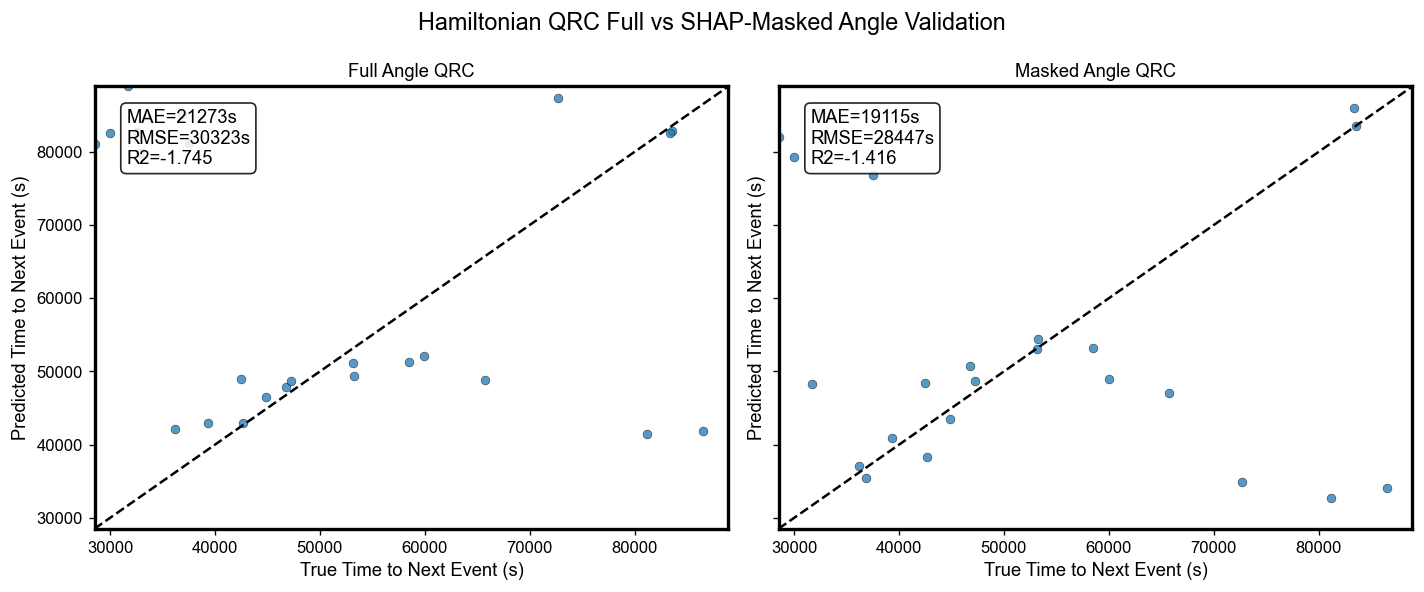

In [78]:
if qrc_mask_validation_results.empty or not qrc_mask_validation_predictions:
    print("No QRC predictions to plot yet. Run the previous cell with RUN_QRC_VALIDATION = True first.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
    plot_specs = [
        ("full_angles", "Full Angle QRC"),
        ("masked_angles", "Masked Angle QRC"),
    ]

    all_true = []
    all_pred = []
    for ax, (feature_set, title) in zip(axes, plot_specs):
        result = qrc_mask_validation_predictions[feature_set]
        y_true_plot = np.asarray(result["y_test"])
        y_pred_plot = np.asarray(result["test_pred"])
        all_true.append(y_true_plot)
        all_pred.append(y_pred_plot)

        ax.scatter(y_true_plot, y_pred_plot, s=28, alpha=0.75, edgecolor="black", linewidth=0.3)
        ax.set_title(title)
        ax.set_xlabel("True Time to Next Event (s)")
        ax.set_ylabel("Predicted Time to Next Event (s)")
        box_axes(ax)

        metrics_row = qrc_mask_validation_results.loc[
            qrc_mask_validation_results["feature_set"] == feature_set
        ].iloc[0]
        ax.text(
            0.05,
            0.95,
            f"MAE={metrics_row['test_mae']:.0f}s\nRMSE={metrics_row['test_rmse']:.0f}s\nR2={metrics_row['test_r2']:.3f}",
            transform=ax.transAxes,
            va="top",
            bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85},
        )

    min_axis = min(np.min(np.concatenate(all_true)), np.min(np.concatenate(all_pred)))
    max_axis = max(np.max(np.concatenate(all_true)), np.max(np.concatenate(all_pred)))
    for ax in axes:
        ax.plot([min_axis, max_axis], [min_axis, max_axis], color="black", linestyle="--", linewidth=1.5)
        ax.set_xlim(min_axis, max_axis)
        ax.set_ylim(min_axis, max_axis)

    fig.suptitle("Hamiltonian QRC Full vs SHAP-Masked Angle Validation", fontsize=14)
    fig.tight_layout()
    plt.show()

## Optional Regime-Classifier SHAP

If routing short/long regimes is a priority, this optional section explains which angle features influence the regime boundary. It is separate from the direct regression selection above.


In [76]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_sample_weight

run_regime_shap = True

if run_regime_shap:
    y_clf_train = (np.asarray(y_train) >= SHORT_THRESHOLD).astype(int)
    y_clf_val = (np.asarray(y_val) >= SHORT_THRESHOLD).astype(int)
    weights = compute_sample_weight("balanced", y_clf_train)
    clf = XGBClassifier(
        objective="binary:logistic",
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        tree_method="hist",
    )
    clf.fit(X_train, y_clf_train, sample_weight=weights, eval_set=[(X_val, y_clf_val)], verbose=False)
    print(f"Regime validation accuracy: {accuracy_score(y_clf_val, clf.predict(X_val)):.4f}")

    clf_shap, clf_shap_method = get_tree_shap_values(clf, X_val, feature_names, list_index=-1)
    print(f"Classifier SHAP extraction method: {clf_shap_method}")
    clf_importance = feature_map.copy()
    clf_importance["mean_abs_shap"] = np.abs(clf_shap).mean(axis=0)
    clf_importance = clf_importance.sort_values("mean_abs_shap", ascending=False)
    display(clf_importance[clf_importance["mean_abs_shap"] > 0.0001].sort_values("mean_abs_shap", ascending=False))
else:
    print("Set run_regime_shap = True to compute classifier/regime SHAP.")


Regime validation accuracy: 0.7841
Classifier SHAP extraction method: xgboost.Booster.predict(pred_contribs=True)


,feature,base_feature,lag,is_previous_event,mean_abs_shap
1,form_fac-0,form_fac,0,False,0.709666
11,tide_height-1,tide_height,1,True,0.650701
2,time_since-0,time_since,0,False,0.402018
5,tide_height-0,tide_height,0,False,0.312602
0,tide_deriv-0,tide_deriv,0,False,0.296655
...,...,...,...,...,...
64,high_t_evt-10,high_t_evt,10,True,0.002212
40,high_t_evt-6,high_t_evt,6,True,0.001614
112,high_t_evt-18,high_t_evt,18,True,0.001500
124,high_t_evt-20,high_t_evt,20,True,0.001100
